In [15]:
import numpy as np
with open('/Users/hba423/codes/brisket-data/BC03/BC03_miles_TopHeavyIMF/bc2003_z008_THIMF_hr_xmilesi_ssp.ised', 'rb') as f:
    data = np.fromfile(f, dtype=np.float32)

In [107]:
# [0.005, 0.02, 0.2, 0.4, 1., 2.5, 5.]

for key in ['m22','m32','m42','m52','m62','m72','m82']:
    with open(f'/Users/hba423/codes/brisket-data/bc03/bc03_miles_chabrier/bc2003_hr_xmiless_{key}_chab_ssp.ised_ASCII', 'r') as f:
        lines = f.readlines()
        print(lines[3])

Padova (1994) + S. Charlot (1997). X=0.7696, Y=0.2303, Z=0.0001                 

Padova (1994) + S. Charlot (1997). X=0.7686, Y=0.231, Z=0.0004                  

Padova (1994) + S. Charlot (1997). X=0.756, Y=0.24, Z=0.004                     

Padova (1994) + S. Charlot (1997). X=0.742, Y=0.25, Z=0.008                     

Padova (1994) + S. Charlot (1997). X=0.70, Y=0.28, Z=0.02                       

Padova (1994) + S. Charlot (1997). X=0.5980, Y=0.352, Z=0.0500                  

Padova (1994) + S. Charlot (1997). X=0.4250, Y=0.475, Z=0.1000                  



Padova (1994) + S. Charlot (1997). X=0.7696, Y=0.2303, Z=0.0001                 



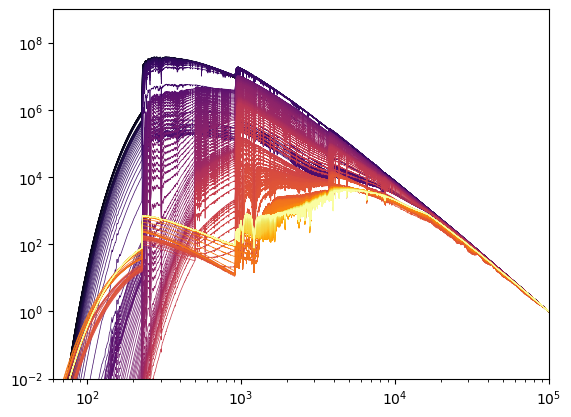

In [106]:
with open('/Users/hba423/codes/brisket-data/bc03/bc03_miles_chabrier/bc2003_hr_xmiless_m22_chab_ssp.ised_ASCII', 'r') as f:
    lines = f.readlines()
    line = lines[0]
    ages = np.array([float(l) for l in line.split()[1:]])
    #print(ages)
    line = lines[6]
    wavs = np.array([float(l) for l in line.split()[1:]])
    seds = np.array([[float(l) for l in line.split()[1:13217]] for line in lines[7:228]])
    print(lines[3])

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
cmap = plt.colormaps['inferno']
for i in range(221):
    ax.loglog(wavs, seds[i]/seds[i][np.argmin(np.abs(wavs-1e5))], linewidth=0.5, color=cmap(i/221))
ax.set_xlim(60, 1e5)
ax.set_ylim(1e-2, 1e9)
plt.show()

In [91]:
seds[0]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       5.82533222e-21, 1.15046071e-21, 2.27726347e-22])

In [ ]:
line

In [14]:
import brisket
import matplotlib.pyplot as plt
import numpy as np

In [2]:

mc = {'redshift':3, 
      'galaxy':{
        'model':'BC03',
        'logMstar':10,
        'metallicity':0.5,
        'sfh':'constant',
        'age_min':0,
        'age_max':0.5,
        'dust_atten':{
            'type':'Calzetti',
            'Av':3,
        },
        }
    }

gal1 = brisket.model_galaxy(mc, logger=brisket.utils.basicLogger)
from copy import copy
mc['galaxy']['dust_emission'] = {'qpah':4.5, 'umin':20, 'gamma':0.5}
gal2 = brisket.model_galaxy(mc, logger=brisket.utils.basicLogger)



16:13:47 :: brisket :: INFO     :: Loading parameter dictionary
16:13:47 :: brisket :: INFO     :: Calculating optimal wavelength sampling for the model...
16:13:47 :: brisket :: INFO     :: Resampling the filter curves onto model wavelength grid...
16:13:47 :: brisket :: INFO     :: Initializing star-formation history module             (sfh: constant)
16:13:47 :: brisket :: INFO     :: Initializing stellar module                              (model: BC03)
16:13:47 :: brisket :: DEBUG    :: Resampling stellar models to model wavelength grid
16:13:47 :: brisket :: DEBUG    :: Resampling the stellar grids to the configured age sampling
16:13:47 :: brisket :: INFO     :: Skipping nebular emission module
16:13:47 :: brisket :: INFO     :: Initializing dust attenuation module                  (type: Calzetti)
16:13:47 :: brisket :: INFO     :: Skipping dust emission module
16:13:47 :: brisket :: DEBUG    :: Computing stellar spectrum
16:13:47 :: brisket :: DEBUG    :: Converting flux units

16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:1

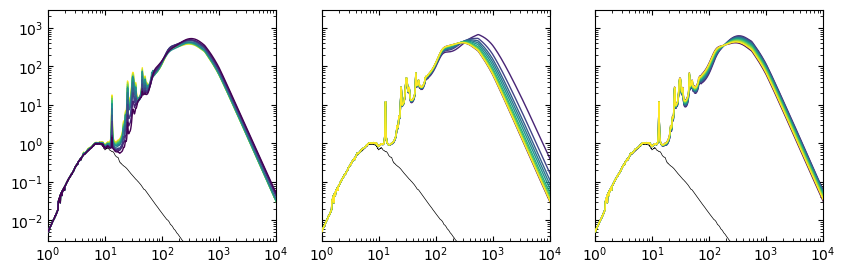

In [47]:
plt.style.use('hba_sans')
fig, axes = plt.subplots(1,3,figsize=(10,3),sharex=True,sharey=True)

for ax in axes: 
    ax.loglog(gal1.wav_obs, gal1.spectrum_full, color='k', linewidth=0.5, zorder=-1000)
    ax.set_xlim(1, 1e4)
    ax.set_ylim(3e-3, 3e3)

cmap = plt.colormaps['viridis']
qpahs = np.linspace(0.15, 4.5, 11)
for i,qpah in enumerate(qpahs):
    mc['galaxy']['dust_emission']['qpah'] = qpah
    gal2.update(mc)
    axes[0].loglog(gal2.wav_obs, gal2.spectrum_full, c=cmap((qpah-qpahs.min())/(qpahs.max()-qpahs.min())), zorder=100-i)

mc['galaxy']['dust_emission']['qpah'] = 3
umins = np.linspace(1, 21, 11)
for i,umin in enumerate(umins):
    gal2.update(mc)
    mc['galaxy']['dust_emission']['umin'] = umin
    axes[1].loglog(gal2.wav_obs, gal2.spectrum_full, c=cmap((umin-umins.min())/(umins.max()-umins.min())), zorder=i)

mc['galaxy']['dust_emission']['umin'] = 20
gammas = np.linspace(0.3,0.7,11)
for i,gamma in enumerate(gammas):
    gal2.update(mc)
    mc['galaxy']['dust_emission']['gamma'] = gamma
    axes[2].loglog(gal2.wav_obs, gal2.spectrum_full, c=cmap((gamma-gammas.min())/(gammas.max()-gammas.min())), zorder=i)


plt.show()